In [ ]:
import os
os.chdir("D:/文章返修/source data/Figure_3/Panel_A")
import matplotlib.pyplot as plt
import numpy as np
from scipy import sparse
import pandas as pd

In [2]:
def classify_rna_data(input_rna, dis, freq, binsize, discard):
    data = input_rna.copy()
    distance = data['E'] - data['S']
    rna_long = data[distance >= dis]
    rna_long_hf = rna_long[rna_long['value'] > freq]
    
    mask_c = (rna_long_hf['S'] <= discard[0]) & (rna_long_hf['value']>discard[1])
    
    hist_data = []
    s = 0
    e = binsize
    lens = data['E'].max()
    while True:
        distance_hf = rna_long_hf[~mask_c]['E'] - rna_long_hf[~mask_c]['S']
        mask = (distance_hf > s) & (distance_hf <= e)
        hist_data.append(rna_long_hf[~mask_c]['value'][mask].sum())
        s = e
        e += binsize
        if e >= lens:
            break
    
    return rna_long_hf[mask_c], rna_long_hf[~mask_c], hist_data

def get_matrix_npz(M1,M2):
    '''
    transform a three tuple into a matrix
    '''
    S1 = sparse.coo_matrix((M1['value'],(np.asarray(M1['S'], dtype='<i4'),np.asarray(M1['E'], dtype= '<i4')))).toarray()
    S2 = sparse.coo_matrix((M2['value'],(np.asarray(M2['E'], dtype='<i4'),np.asarray(M2['S'], dtype= '<i4')))).toarray()
    matrix = np.zeros((max(S2.shape),max(S1.shape)))
    matrix[np.nonzero(S1)] = S1[np.nonzero(S1)]
    matrix[np.nonzero(S2)] = S2[np.nonzero(S2)]
    return matrix

def extract_matrix(file_dir, file_name, res):
    data = np.loadtxt(file_dir + file_name, usecols=[0,1,2], dtype=[('S','<i4'),('E','<i4'),('value','<f8')])
    data['S'] = data['S'] / res
    data['E'] = data['E'] / res
    data['value'][data['value'] < 0] = 0
    data['value'][np.isnan(data['value'])] = 0
    mat = get_matrix_npz(data, data)
    return mat

res = 5
cmap = 'Reds'
file_dir = "./"

S 15 115 20580 20680
E 15 115 25385 25485
M 15 115 25630 25730
N 15 115 26320 26420


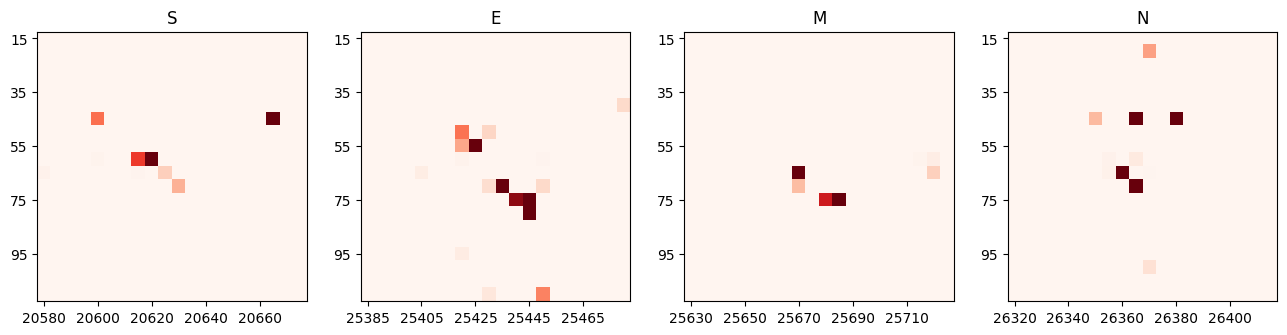

In [3]:
ma_pedv_ric_cell_kr = extract_matrix(file_dir, 'PEDV_in_cell.5nt.KR.matrix', res)
trs_b = [20620, 25425, 25672, 26360]
trs_b_label = ['S','E', 'M', 'N']

plt.figure(figsize=(16,8))
start_list = np.arange(25,125)
end_list = np.array([])
for i,trs in enumerate(trs_b):
    trs += 10
    s1 = int((65 - 50) / res)
    e1 = int((65 + 50) / res)
    s2 = int((trs - 50) / res)
    e2 = int((trs + 50) / res)

    stp = int(20 / res)
    plt.subplot(2,4,i+1)
    vmax = 15
    plt.imshow(ma_pedv_ric_cell_kr[s1:e1, s2:e2], cmap= plt.get_cmap(cmap), vmax=vmax, vmin=0)
    print(trs_b_label[i],s1*5,e1*5,s2*5,e2*5)
    plt.yticks(np.arange(0,e1-s1,stp),np.arange(s1,e1,stp) * res)
    plt.xticks(np.arange(0,e2-s2,stp),np.arange(s2,e2,stp) * res)
    plt.title(trs_b_label[i])
    end_list = np.hstack([end_list, np.arange(trs-50,trs+50)])
col_list = np.array(start_list / res, dtype='<i4')
raw_list = np.array(end_list / res, dtype='<i4')

In [4]:
pedv_matrix = []

for i,trs in enumerate(trs_b):
    trs += 10
    s1 = int((65 - 50) / res)
    e1 = int((65 + 50) / res)
    s2 = int((trs - 50) / res)
    e2 = int((trs + 50) / res)

    stp = int(20 / res)
    pedv_matrix.append(ma_pedv_ric_cell_kr[s1:e1, s2:e2])

sheets = {
    'PEDV_S': pedv_matrix[0],
    'PEDV_E': pedv_matrix[1],
    'PEDV_M': pedv_matrix[2],
    'PEDV_N': pedv_matrix[3]
}

output_path = 'PEDV.xlsx'

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    for sheet_name, matrix in sheets.items():
        df = pd.DataFrame(
            matrix,
            index=[f'Row_{i}' for i in range(matrix.shape[0])],
            columns=[f'Col_{j}' for j in range(matrix.shape[1])]
        )
        df.to_excel(writer, sheet_name=sheet_name, index=True)

In [5]:
rna_seq_24_all = np.loadtxt(file_dir + '2_beta_SARS-CoV-2-9_all-rep-rna.1nt.none.matrix', usecols=[0,1,2]
                  , dtype=[('S','<f8'),('E','<f8'),('value','<f8')])
rna_c, rna_nc, hist_data = classify_rna_data(rna_seq_24_all, 20, res, 100, [75,100])

S 15 115 21505 21605
E 15 115 26185 26285
M 15 115 26420 26520
N 15 115 28210 28310


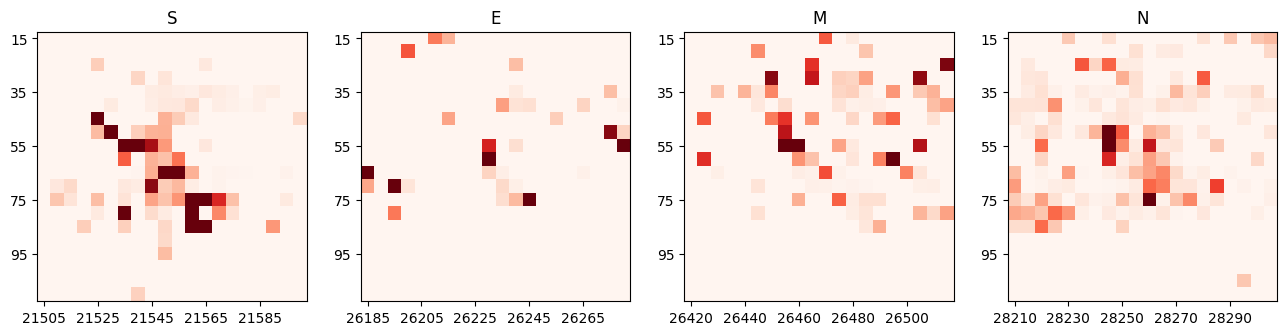

In [6]:
can_transcrpt = rna_c[rna_c['value'] > 1000] 
trs_b = [21556, 26237, 26460, 28260]
trs_b_label = ['S', 'E', 'M', 'N']
ma_sars_ric_cell_kr = extract_matrix(file_dir, 'virus.inCell.Vero.5nt.KR.matrix', res)
vmax = 15
cmap = 'Reds'
plt.figure(figsize=(16,8))
start_list = np.arange(25,125)
end_list = np.array([])
for i,trs in enumerate(trs_b):
    if i == 2:
        trs += 10
    s1 = int((75 - 50) / res) - 2
    e1 = int((75 + 50) / res) - 2
    s2 = int((trs - 50) / res) 
    e2 = int((trs + 50) / res) 

    stp = int(20 / res)
    plt.subplot(2,4,i+1)
    vmax = vmax
    plt.imshow(ma_sars_ric_cell_kr[s1:e1, s2:e2], cmap= plt.get_cmap(cmap), vmax=vmax, vmin=0)
    print(trs_b_label[i],s1*5,e1*5,s2*5,e2*5)
    plt.yticks(np.arange(0,e1-s1,stp),np.arange(s1,e1,stp) * res)
    plt.xticks(np.arange(0,e2-s2,stp),np.arange(s2,e2,stp) * res)
    plt.title(trs_b_label[i])
    end_list = np.hstack([end_list, np.arange(trs-50,trs+50)])
col_list = np.array(start_list / res, dtype='<i4')
raw_list = np.array(end_list / res, dtype='<i4')

In [7]:
sars2_matrix = []

for i,trs in enumerate(trs_b):
    if i == 2:
        trs += 10
    s1 = int((75 - 50) / res) - 2
    e1 = int((75 + 50) / res) - 2
    s2 = int((trs - 50) / res) 
    e2 = int((trs + 50) / res) 

    sars2_matrix.append(ma_sars_ric_cell_kr[s1:e1, s2:e2])

sheets = {
    'SARS-CoV-2_S': sars2_matrix[0],
    'SARS-CoV-2_E': sars2_matrix[1],
    'SARS-CoV-2_M': sars2_matrix[2],
    'SARS-CoV-2_N': sars2_matrix[3]
}

output_path = 'SARS-CoV-2.xlsx'

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    for sheet_name, matrix in sheets.items():
        df = pd.DataFrame(
            matrix,
            index=[f'Row_{i}' for i in range(matrix.shape[0])],
            columns=[f'Col_{j}' for j in range(matrix.shape[1])]
        )
        df.to_excel(writer, sheet_name=sheet_name, index=True)

S 15 115 21360 21460
E 15 115 27540 27640
M 15 115 27790 27890
N 15 115 28495 28595


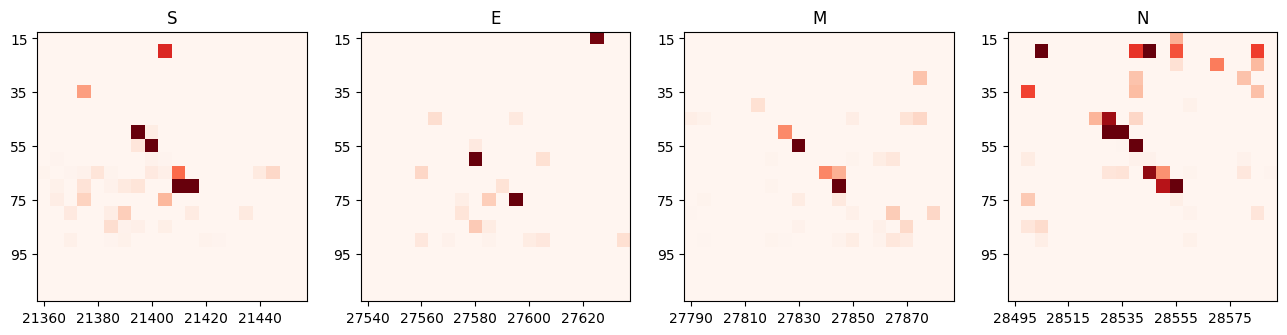

In [8]:
trs_b = [21401, 27581, 27833, 28535]
trs_b_label = ['S','E', 'M', 'N']

ma_mers_com_cell = extract_matrix(file_dir, 'MERS-comrades-PRJNA646969-Huh7-20h-gRNA-KR-5BP.matrix', res)
plt.figure(figsize=(16,8))
start_list = np.arange(25,125)
end_list = np.array([])
for i,trs in enumerate(trs_b):
    trs += 10
    s1 = int((65 - 50) / res)
    e1 = int((65 + 50) / res)
    s2 = int((trs - 50) / res)
    e2 = int((trs + 50) / res)

    stp = int(20 / res)
    plt.subplot(2,4,i+1)
    vmax = vmax
    plt.imshow(ma_mers_com_cell[s1:e1, s2:e2], cmap= plt.get_cmap(cmap), vmax=vmax, vmin=0)
    print(trs_b_label[i],s1*5,e1*5,s2*5,e2*5)
    plt.yticks(np.arange(0,e1-s1,stp),np.arange(s1,e1,stp) * res)
    plt.xticks(np.arange(0,e2-s2,stp),np.arange(s2,e2,stp) * res)
    plt.title(trs_b_label[i])
    end_list = np.hstack([end_list, np.arange(trs-50,trs+50)])
col_list = np.array(start_list / res, dtype='<i4')
raw_list = np.array(end_list / res, dtype='<i4')

In [9]:
mers_matrix = []

for i,trs in enumerate(trs_b):
    trs += 10
    s1 = int((65 - 50) / res)
    e1 = int((65 + 50) / res)
    s2 = int((trs - 50) / res)
    e2 = int((trs + 50) / res)

    mers_matrix.append(ma_mers_com_cell[s1:e1, s2:e2])

sheets = {
    'MERS-CoV_S': mers_matrix[0],
    'MERS-CoV_E': mers_matrix[1],
    'MERS-CoV_M': mers_matrix[2],
    'MERS-CoV_N': mers_matrix[3]
}

output_path = 'MERS-CoV.xlsx'

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    for sheet_name, matrix in sheets.items():
        df = pd.DataFrame(
            matrix,
            index=[f'Row_{i}' for i in range(matrix.shape[0])],
            columns=[f'Col_{j}' for j in range(matrix.shape[1])]
        )
        df.to_excel(writer, sheet_name=sheet_name, index=True)

S 25 125 19130 19230
E 25 125 22715 22815
M 25 125 22965 23065
N 25 125 23940 24040


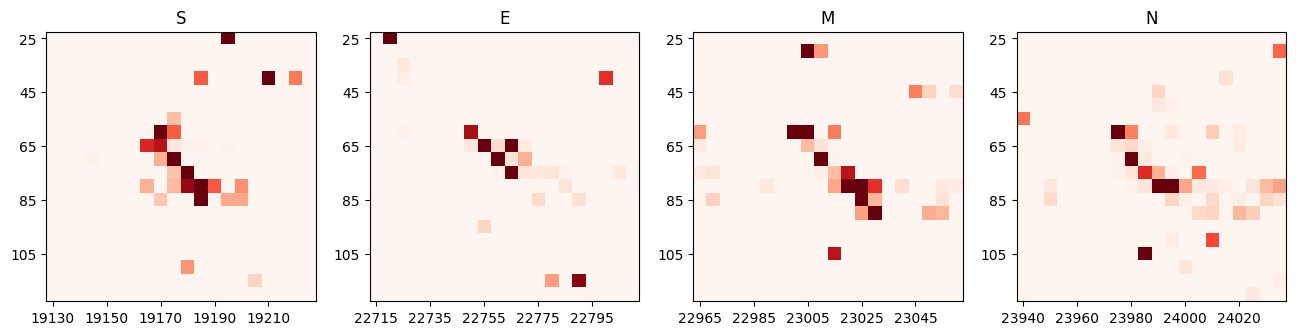

In [10]:
trs_b = [19161, 22746, 22996, 23971]
trs_b_label = ['S', 'E', 'M', 'N']

ma_ric_pdcov_cell = extract_matrix(file_dir, 'pdcov_in_Cell.5nt.KR.matrix', res)
fig = plt.figure(figsize=(16,8))
start_list = np.arange(25,125)
end_list = np.array([])
for i,trs in enumerate(trs_b):
    trs += 10

    s1 = int((75 - 50) / res)
    e1 = int((75 + 50) / res)
    s2 = int((trs - 50) / res) + 2
    e2 = int((trs + 50) / res) + 2

    stp = int(20 / res)
    plt.subplot(2,4,i+1)
    vmax = vmax
    plt.imshow(ma_ric_pdcov_cell[s1:e1, s2:e2], cmap= plt.get_cmap(cmap), vmax=vmax, vmin=0)
    print(trs_b_label[i],s1*5,e1*5,s2*5,e2*5)
    plt.yticks(np.arange(0,e1-s1,stp),np.arange(s1,e1,stp) * res)
    plt.xticks(np.arange(0,e2-s2,stp),np.arange(s2,e2,stp) * res)
    plt.title(trs_b_label[i])
    end_list = np.hstack([end_list, np.arange(trs-50,trs+50)])
col_list = np.array(start_list / res, dtype='<i4')
raw_list = np.array(end_list / res, dtype='<i4')

In [11]:
pdcov_matrix = []

for i,trs in enumerate(trs_b):
    trs += 10

    s1 = int((75 - 50) / res)
    e1 = int((75 + 50) / res)
    s2 = int((trs - 50) / res) + 2
    e2 = int((trs + 50) / res) + 2

    pdcov_matrix.append(ma_ric_pdcov_cell[s1:e1, s2:e2])

sheets = {
    'PDCoV_S': pdcov_matrix[0],
    'PDCoV_E': pdcov_matrix[1],
    'PDCoV_M': pdcov_matrix[2],
    'PDCoV_N': pdcov_matrix[3]
}

output_path = 'PDCoV.xlsx'

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    for sheet_name, matrix in sheets.items():
        df = pd.DataFrame(
            matrix,
            index=[f'Row_{i}' for i in range(matrix.shape[0])],
            columns=[f'Col_{j}' for j in range(matrix.shape[1])]
        )
        df.to_excel(writer, sheet_name=sheet_name, index=True)